In [1]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns
import pickle

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu
from src import prune 

from train_mod_cog import RNNModel
import networkx as nx

device = eg_utils.get_device()

['/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf


In [2]:
%load_ext autoreload
%autoreload 2

## Prerequisites

Run `script_clustering_analysis.py`, `script_shortest_path_analysis.py` first.

These write `{eg,gd}_{seed}_{sparsity}_node_ccs.pkl`, `{eg,gd}_shortest_path_results.csv` files to `/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering`.

## Notebook structure:

1. Load models, binarise & threshold by weight magnitude.
2. Analyse directed and undirected clustering coefficients.

In [3]:
import os
os.getcwd()

'/home/mila/c/cornforj/eg_rnns/mod_cog/analysis'

In [4]:
from script_clustering_analysis import (
    load_model,
    get_results_dict,
    load_rnn,
    prune_wrec,
    get_weight_hh,
    clean_weights,
    calculate_node_clustering_coefs,
)

In [5]:
def prune_wrec(rnn_module, prune_prop = 0.9, inverse_magnitude=False):
    prune.global_unstructured([(rnn_module, "weight_hh")], 
                          pruning_method=prune.L1Unstructured,
                          amount=prune_prop,inverse_magnitude=inverse_magnitude)
    prune.remove(rnn_module, "weight_hh")

In [6]:
#  Get final experiments 
linclab_drive  = Path("/network/projects/_groups/linclab_users/eg/")
results_dir = linclab_drive/"modcog/exp8_final_combined"
results_dict = get_results_dict(results_dir)
print("Results loaded", results_dict.keys())

# load lognormal experiments
gd_exps_dict = results_dict.gd_log_normal 
eg_exps_dict = results_dict.eg_log_normal

gd_exp_list = [d for k,d in gd_exps_dict.items() if k.startswith("seed")]
eg_exp_list = [d for k,d in eg_exps_dict.items() if k.startswith("seed")]
seeds_keylist = [k for k in eg_exps_dict.keys() if k.startswith("seed")]
n_seeds = len(seeds_keylist)

all_exps_list = gd_exp_list[:n_seeds] + eg_exp_list[:n_seeds]

Results loaded dict_keys(['eg_log_normal', 'eg_normal', 'eg_uniform', 'gd_log_normal', 'gd_normal', 'gd_uniform'])


In [7]:
# load models to test on task
seed_idx = 0
eg_run = eg_exp_list[seed_idx]
gd_run = gd_exp_list[seed_idx]
eg_rnn = load_rnn(eg_run)
gd_rnn = load_rnn(gd_run)

Setting split bias


/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/../../src/analysis_utils.py:151: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location

In [8]:
pp = 0.99
prune_wrec(eg_rnn,prune_prop = pp, inverse_magnitude=False)
prune_wrec(gd_rnn,prune_prop = pp, inverse_magnitude=False)

In [9]:
gd_wrec = get_weight_hh(gd_rnn)
eg_wrec = get_weight_hh(eg_rnn)
gEG = clean_weights(eg_wrec, abs_weights=True)
gGD = clean_weights(gd_wrec, abs_weights=True) 

In [70]:
eg_clusterings = calculate_node_clustering_coefs(gEG)
gd_clusterings = calculate_node_clustering_coefs(gGD)

In [72]:
gd_clusterings[0].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [75]:
# plot histograms of clustering coefs
eg_c = "#f05039" # orangey red
gd_c = "#1f449c" # blue
fig_path = Path("../figs/fig_sw_analysis/")

Undirected seed_5
0.16666666666666666
../figs/fig_sw_analysis/Undirected seed_5.pdf
Directed seed_5
0.08333333333333333
../figs/fig_sw_analysis/Directed seed_5.pdf


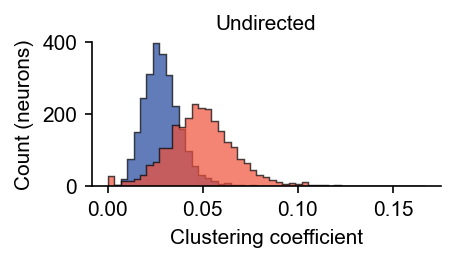

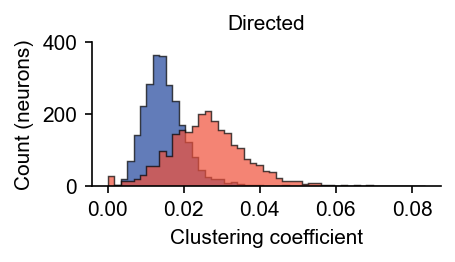

In [ ]:


clustering_types = ["Undirected", "Directed",]
for idx, clustering_title in enumerate(clustering_types):
    print(f"{clustering_title} {seeds_keylist[seed_idx]}")
    gd_ccs = list(gd_clusterings[idx].values())
    eg_ccs = list(eg_clusterings[idx].values()) 
    max_x = max(max(gd_ccs), max(eg_ccs))
    print(max_x)
    bin_linspace = np.linspace(0, max_x, 50)

    gd_counts, gd_bin_edges = np.histogram(gd_ccs, bin_linspace)
    eg_counts, eg_bin_edges = np.histogram(eg_ccs, bin_linspace)

    fig = plt.figure(figsize=(3.,1.25), dpi=150)
    plt.ylim(0,400)
    plt.stairs(gd_counts, gd_bin_edges, fill=True, alpha=0.7, color=gd_c, edgecolor='black', linewidth=0.7, label="GD")
    plt.stairs(eg_counts, eg_bin_edges, fill=True, alpha=0.7, color=eg_c, edgecolor='black', linewidth=0.7, label="EG")
    plt.xlabel("Clustering coefficient")
    plt.ylabel("Count (neurons)")
    plt.title(f"{clustering_title}")# Clustering\n {seeds_keylist[seed_idx]}")
    #plt.legend()
    sns.despine()
    plt.savefig(fig_path/f"{clustering_title} {seeds_keylist[seed_idx]}.png",bbox_inches="tight", transparent=True) 
    plt.savefig(fig_path/f"{clustering_title} {seeds_keylist[seed_idx]}.pdf", bbox_inches="tight", transparent=True)

    print(fig_path/f"{clustering_title} {seeds_keylist[seed_idx]}.pdf")

In [13]:
average_clustering_eg = nx.average_clustering(gEG.to_undirected(), weight=None)
average_clustering_eg

0.049010521846152184

In [14]:
average_clustering_eg = nx.average_clustering(gEG, weight=None)
average_clustering_eg

0.02622341505752911

In [ ]:
np.mean(list(eg_clusterings[1].values()))

## Plot the mean cc for top 1% weights over seeds

In [15]:
# script_clustering_analysis.py saves this analysis to pkl files
gd_seed_ccs = []
eg_seed_ccs = []

pp = 0.99
for seed_idx in range(n_seeds):
    savedir = Path("/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering")
    fname_eg = f"eg_{seeds_keylist[seed_idx]}_{pp}_node_ccs.pkl"
    fname_gd = f"gd_{seeds_keylist[seed_idx]}_{pp}_node_ccs.pkl"

    eg_path = savedir / fname_eg
    gd_path = savedir / fname_gd

    with open(eg_path, "rb") as f:
        eg_ccs_undirected, eg_ccs_directed = pickle.load(f)

    with open(gd_path, "rb") as f:
        gd_ccs_undirected, gd_ccs_directed = pickle.load(f)

    eg_seed_ccs.append(np.mean(list(eg_ccs_directed.values())))
    gd_seed_ccs.append(np.mean(list(gd_ccs_directed.values())))

In [16]:
gd_seed_ccs

[np.float64(0.014983649027182497),
 np.float64(0.015049412498213411),
 np.float64(0.015313002263671069),
 np.float64(0.015814203636078914),
 np.float64(0.014436794391840448)]

In [17]:
eg_seed_ccs

[np.float64(0.026223415057529054),
 np.float64(0.02617427260581087),
 np.float64(0.026222443489428548),
 np.float64(0.025761798250461317),
 np.float64(0.025758053556982845)]

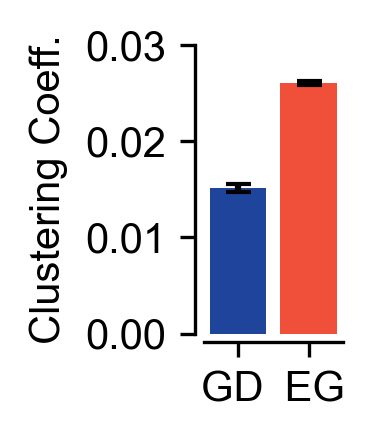

In [18]:
gd = np.asarray(gd_seed_ccs, dtype=float)
eg = np.asarray(eg_seed_ccs, dtype=float)

means = [gd.mean(),eg.mean()]
std_devs = [gd.std(),eg.std()]

exp_labels = ["GD ", " EG"]
colours = [gd_c,eg_c]

plt.figure(figsize=(0.6,1.25), dpi = 300)

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3, width=0.8)
plt.ylim(0,0.03)
plt.ylabel("Clustering Coeff.")
sns.despine(offset=2)

plt.savefig(fig_path/f"directed_99_cc.pdf", bbox_inches="tight", transparent=True)

In [19]:
from scipy.stats import ttest_ind

res = ttest_ind(gd, eg, equal_var=False)
test_label = f"Welch t p={res.pvalue:.3g}"


# Plot the cluster coeffs over weight sparsities

As above, load pkl files created by script_clustering_analysis.py


In [61]:
prune_proportions = [0.99, 0.98, 0.97, 0.96, 0.95]

eg_mean_ccs = {str(pp): [] for pp in prune_proportions}
gd_mean_ccs = {str(pp): [] for pp in prune_proportions}

for pp in prune_proportions:
    for seed_idx in range(n_seeds):
        savedir = Path("/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering")
        fname_eg = f"eg_{seeds_keylist[seed_idx]}_{pp}_node_ccs.pkl"
        fname_gd = f"gd_{seeds_keylist[seed_idx]}_{pp}_node_ccs.pkl"

        eg_path = savedir / fname_eg
        gd_path = savedir / fname_gd

        with open(eg_path, "rb") as f:
            eg_ccs_undirected, eg_ccs_directed = pickle.load(f)

        with open(gd_path, "rb") as f:
            gd_ccs_undirected, gd_ccs_directed = pickle.load(f)

        eg_mean_ccs[str(pp)].append(np.mean(list(eg_ccs_directed.values())))
        gd_mean_ccs[str(pp)].append(np.mean(list(gd_ccs_directed.values())))

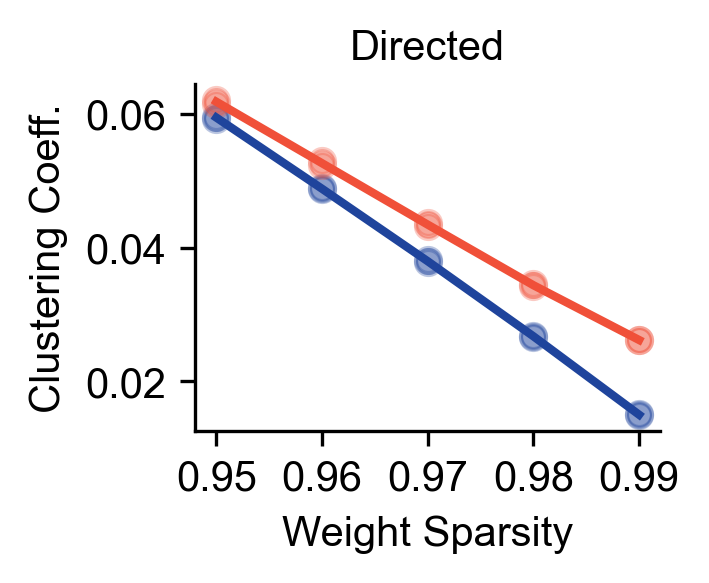

In [63]:
gd_df = pd.DataFrame(gd_mean_ccs)
eg_df = pd.DataFrame(eg_mean_ccs)

gd_df = gd_df[sorted(gd_df.columns)]
eg_df = eg_df[sorted(eg_df.columns)]

x_vals = eg_df.columns

plt.figure(figsize=(2.,1.5), dpi = 300)

# GD
for i, row in gd_df.iterrows():
    plt.scatter(x_vals, row.values, color=gd_c, alpha=0.3)  # alpha makes it faint

# EG
for i, row in eg_df.iterrows():
    plt.scatter(x_vals, row.values, color=eg_c, alpha=0.3)  # alpha makes it faint

mean_vals = eg_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=eg_c, linewidth=2, label="EG")
mean_vals = gd_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=gd_c, linewidth=2, label="GD")

sns.despine(trim=False)

plt.ylabel("Clustering Coeff.")
plt.xlabel("Weight Sparsity")
plt.title("Directed")

plt.savefig(fig_path/f"directed_sparsities_cc.pdf", bbox_inches="tight", transparent=True)


# Shortest path plotting

Load and plot results from `script_shortest_path_analysis.py` (writes
eg/gd_shortest_path_results.csv to the analysis/clustering dir).

In [64]:
savedir = Path("/network/projects/_groups/linclab_users/eg/modcog/analysis/clustering")
eg_df = pd.read_csv(Path(savedir/"eg_shortest_path_results.csv"), index_col=0)
gd_df = pd.read_csv(Path(savedir/"gd_shortest_path_results.csv"), index_col=0)

In [65]:
eg_df

,0.99,0.98,0.97,0.96,0.95
0,2.754521,2.354319,2.114156,2.002487,1.959700
1,2.752221,2.352900,2.111072,2.000487,1.958841
2,2.754850,2.356105,2.112687,2.001017,1.958996
3,2.752508,2.353527,2.111559,2.000769,1.959108
4,2.764588,2.358318,2.114520,2.001785,1.959204


In [66]:
gd_df

,0.99,0.98,0.97,0.96,0.95
0,2.770972,2.362068,2.107252,1.997810,1.958450
1,2.768720,2.360535,2.105467,1.996820,1.957966
2,2.768496,2.360285,2.105866,1.997033,1.958008
3,2.768073,2.359156,2.105125,1.996415,1.957784
4,2.772147,2.361864,2.105576,1.996633,1.957895


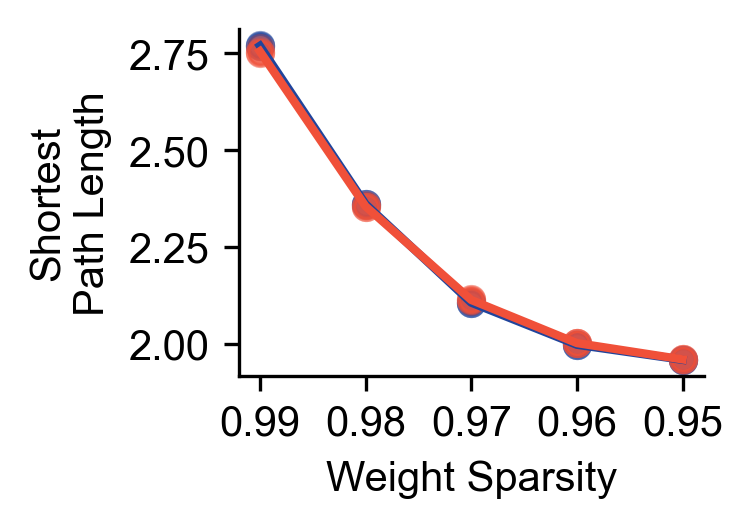

In [77]:
x_vals = eg_df.columns

plt.figure(figsize=(2.,1.5), dpi = 300)

# GD
for i, row in gd_df.iterrows():
    plt.scatter(x_vals, row.values, color=gd_c, alpha=0.3)  # alpha makes it faint

# EG
for i, row in eg_df.iterrows():
    plt.scatter(x_vals, row.values, color=eg_c, alpha=0.3)  # alpha makes it faint

mean_vals = gd_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=gd_c, linewidth=2, label="GD")
mean_vals = eg_df.mean(axis=0)
plt.plot(x_vals, mean_vals, color=eg_c, linewidth=2, label="EG")


sns.despine(offset=0, trim=False)

plt.ylabel("Shortest\nPath Length")
plt.xlabel("Weight Sparsity")
#lt.title("Directed")

plt.savefig(fig_path/f"average_shortest_path_length.pdf", bbox_inches="tight", transparent=True)

In [74]:
fig_path

PosixPath('../figs/clustering')